## 1. Install & Import Libraries

In [1]:
!pip install torch torchvision scikit-learn matplotlib seaborn pandas

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)


[notice] A new release of pip available: 22.2.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Device: cpu


## 2. Load Dataset




In [ ]:
data = pd.read_csv('dermatology.data', header=None)
data = data.replace('?', np.nan).dropna()

X = data.iloc[:, :-1].values.astype(float)
y = data.iloc[:, -1].values.astype(int)

scaler = StandardScaler()
X = scaler.fit_transform(X)

print('Shape:', X.shape)          
print('Classes:', np.unique(y))   

Shape: (358, 34)
Classes: [1 2 3 4 5 6]


## 3. Meta-Learning Class Split

Split 6 disease classes into 4 **seen** (train/test) and 2 **unseen** (zero-shot evaluation).



In [ ]:
unique_classes = np.unique(y)
np.random.seed(42)
np.random.shuffle(unique_classes)

seen_classes   = unique_classes[:4]
unseen_classes = unique_classes[4:]
print('Seen classes  :', seen_classes)
print('Unseen classes:', unseen_classes)

X_seen   = X[np.isin(y, seen_classes)]
y_seen   = y[np.isin(y, seen_classes)]
X_unseen = X[np.isin(y, unseen_classes)]
y_unseen = y[np.isin(y, unseen_classes)]

X_seen_train, X_seen_test, y_seen_train, y_seen_test = train_test_split(
    X_seen, y_seen, test_size=0.20, random_state=42, stratify=y_seen
)
print(f'\nSeen train : {X_seen_train.shape[0]} samples')
print(f'Seen test  : {X_seen_test.shape[0]} samples')
print(f'Unseen     : {X_unseen.shape[0]} samples')

Seen classes  : [1 2 6 3]
Unseen classes: [5 4]

Seen train : 209 samples
Seen test  : 53 samples
Unseen     : 96 samples


## 4. Embedding Network (shared by Prototypical Net)

In [4]:
class EmbeddingNet(nn.Module):
    def __init__(self, input_dim, embedding_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, embedding_dim)
        )
    def forward(self, x):
        return self.net(x)

embedding_net = EmbeddingNet(X.shape[1]).to(device)
optimizer     = optim.Adam(embedding_net.parameters(), lr=0.001)
criterion     = nn.CrossEntropyLoss()
print(embedding_net)

EmbeddingNet(
  (net): Sequential(
    (0): Linear(in_features=34, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
  )
)


## 5. Episode Sampling Helper

In [5]:
def create_episode(X, y, n_way, n_shot, n_query):
    classes = np.random.choice(np.unique(y), n_way, replace=False)
    support_x, support_y, query_x, query_y = [], [], [], []
    for i, cls in enumerate(classes):
        cls_idx  = np.where(y == cls)[0]
        selected = np.random.choice(cls_idx, n_shot + n_query, replace=False)
        support_x.append(X[selected[:n_shot]])
        support_y.append([i] * n_shot)
        query_x.append(X[selected[n_shot:]])
        query_y.append([i] * n_query)
    return (
        torch.tensor(np.vstack(support_x), dtype=torch.float32).to(device),
        torch.tensor(np.hstack(support_y)).to(device),
        torch.tensor(np.vstack(query_x),   dtype=torch.float32).to(device),
        torch.tensor(np.hstack(query_y)).to(device),
    )

## 6. Train Prototypical Network

Trained only on X_seen_train (the 80 % split).  
previous code trained on all of X_seen, which leaked test samples.
embedding_net.train()

for episode in range(300):
    support_x, support_y, query_x, query_y = create_episode(
        X_seen_train, y_seen_train, n_way=3, n_shot=5, n_query=5
    )
    support_emb = embedding_net(support_x)
    query_emb   = embedding_net(query_x)

    prototypes = torch.stack([support_emb[support_y == i].mean(0) for i in range(3)])
    dists = torch.cdist(query_emb, prototypes)
    loss  = criterion(-dists, query_y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

print('ProtoNet training complete')

Training fresh model with loss logging (300 episodes)...


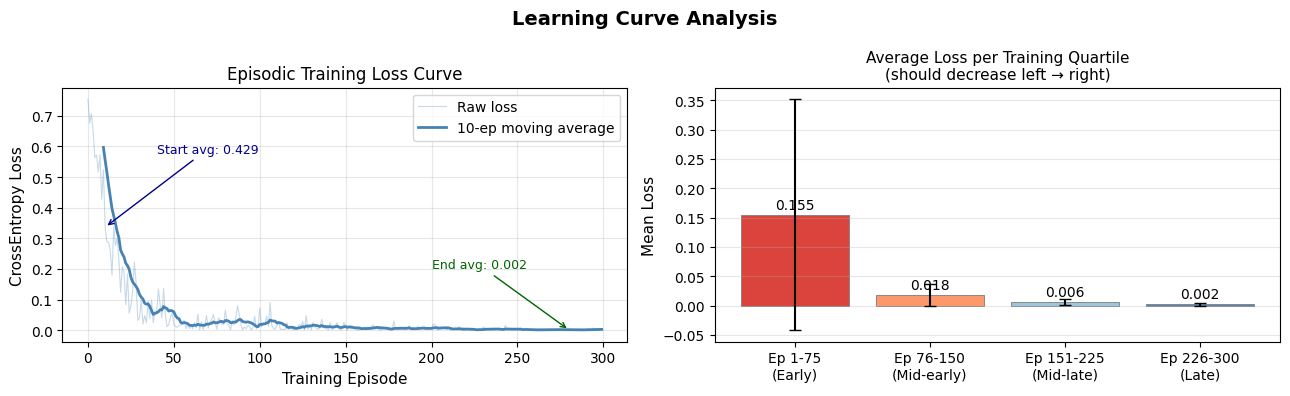

Loss dropped from 0.429 → 0.002  (99.5% reduction)
✓ Clear learning signal — embedding network improved over training.


In [25]:
# Trains a fresh model so the full loss curve is captured from episode 1
print('Training fresh model with loss logging (300 episodes)...')

class EmbeddingNetLC(nn.Module):
    def __init__(self, input_dim, embedding_dim=32):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(input_dim, 64), nn.ReLU(),
                                 nn.Linear(64, embedding_dim))
    def forward(self, x): return self.net(x)

net_lc  = EmbeddingNetLC(X.shape[1]).to(device)
opt_lc  = optim.Adam(net_lc.parameters(), lr=0.001)
crit_lc = nn.CrossEntropyLoss()

all_losses = []
net_lc.train()
for ep in range(300):
    sx, sy, qx, qy = create_episode(X_seen_train, y_seen_train, 3, 5, 5)
    se, qe = net_lc(sx), net_lc(qx)
    proto  = torch.stack([se[sy == i].mean(0) for i in range(3)])
    loss   = crit_lc(-torch.cdist(qe, proto), qy)
    opt_lc.zero_grad(); loss.backward(); opt_lc.step()
    all_losses.append(loss.item())

window         = 10
smoothed       = [np.mean(all_losses[i - window + 1:i + 1])
                  for i in range(window - 1, len(all_losses))]
start_loss     = np.mean(all_losses[:20])
end_loss       = np.mean(all_losses[-20:])

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
ax.plot(all_losses, alpha=0.3, color='steelblue', linewidth=0.8, label='Raw loss')
ax.plot(range(window - 1, 300), smoothed, color='steelblue',
        linewidth=2, label=f'{window}-ep moving average')
ax.set_xlabel('Training Episode', fontsize=11)
ax.set_ylabel('CrossEntropy Loss', fontsize=11)
ax.set_title('Episodic Training Loss Curve', fontsize=12)
ax.legend(fontsize=10); ax.grid(alpha=0.3)
ax.annotate(f'Start avg: {start_loss:.3f}', xy=(10, all_losses[10]),
            xytext=(40, start_loss + 0.15), fontsize=9, color='darkblue',
            arrowprops=dict(arrowstyle='->', color='darkblue'))
ax.annotate(f'End avg: {end_loss:.3f}', xy=(280, all_losses[280]),
            xytext=(200, end_loss + 0.2), fontsize=9, color='darkgreen',
            arrowprops=dict(arrowstyle='->', color='darkgreen'))

ax2 = axes[1]
q_size        = 75
q_means       = [np.mean(all_losses[i * q_size:(i + 1) * q_size]) for i in range(4)]
q_stds        = [np.std(all_losses[i * q_size:(i + 1) * q_size])  for i in range(4)]
q_labels      = ['Ep 1-75\n(Early)', 'Ep 76-150\n(Mid-early)',
                 'Ep 151-225\n(Mid-late)', 'Ep 226-300\n(Late)']
q_colors      = ['#d73027', '#fc8d59', '#91bfdb', '#4575b4']
bars          = ax2.bar(q_labels, q_means, yerr=q_stds, capsize=4,
                        color=q_colors, edgecolor='grey', linewidth=0.7, alpha=0.9)
ax2.set_ylabel('Mean Loss', fontsize=11)
ax2.set_title('Average Loss per Training Quartile\n(should decrease left → right)', fontsize=11)
for bar, val in zip(bars, q_means):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Learning Curve Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

drop = (start_loss - end_loss) / start_loss * 100
print(f'Loss dropped from {start_loss:.3f} → {end_loss:.3f}  ({drop:.1f}% reduction)')
if drop > 10:
    print('✓ Clear learning signal — embedding network improved over training.')
else:
    print('⚠ Minimal reduction — try more episodes or a larger embedding network.')

## 7. Evaluate Prototypical Network on Unseen Classes

**Fixes applied:**
- Removed duplicate embedding computation 
- Averaged over 50 episodes for stable accuracy estimate 
- Shows ground-truth vs predicted for the first 2 episodes

In [ ]:
def evaluate_protonet(X_eval, y_eval, n_way, n_shot, n_episodes=50, verbose_episodes=2):
    accs = []
    embedding_net.eval()

    for ep in range(n_episodes):
        with torch.no_grad():                           
            support_x, support_y, query_x, query_y = create_episode(
                X_eval, y_eval, n_way, n_shot, n_query=5
            )
            support_emb = embedding_net(support_x)     
            query_emb   = embedding_net(query_x)

            prototypes = torch.stack(
                [support_emb[support_y == i].mean(0) for i in range(n_way)]
            )
            dists = torch.cdist(query_emb, prototypes)
            preds = torch.argmin(dists, dim=1)

        gt   = query_y.cpu().numpy()
        pred = preds.cpu().numpy()
        acc  = accuracy_score(gt, pred)
        accs.append(acc)

        if ep < verbose_episodes:
            print(f'  Episode {ep+1} | Ground truth: {gt}')
            print(f'  Episode {ep+1} | Predicted   : {pred}')
            print(f'  Episode {ep+1} | Accuracy    : {acc:.2f}\n')

    mean_acc = float(np.mean(accs))
    std_acc  = float(np.std(accs))
    print(f'ProtoNet {n_shot}-shot {n_way}-way | '
          f'Mean Acc: {mean_acc:.4f} \u00b1 {std_acc:.4f}  (over {n_episodes} episodes)')
    return mean_acc

print('=== ProtoNet on UNSEEN classes ===\n')
proto_acc_1shot = evaluate_protonet(X_unseen, y_unseen, n_way=2, n_shot=1, n_episodes=50)
print()
proto_acc_5shot = evaluate_protonet(X_unseen, y_unseen, n_way=2, n_shot=5, n_episodes=50)

=== ProtoNet on UNSEEN classes ===

  Episode 1 | Ground truth: [0 0 0 0 0 1 1 1 1 1]
  Episode 1 | Predicted   : [0 0 0 0 1 0 0 0 1 0]
  Episode 1 | Accuracy    : 0.50

  Episode 2 | Ground truth: [0 0 0 0 0 1 1 1 1 1]
  Episode 2 | Predicted   : [0 0 0 0 0 1 0 1 1 1]
  Episode 2 | Accuracy    : 0.90

ProtoNet 1-shot 2-way | Mean Acc: 0.8640 ± 0.1397  (over 50 episodes)

  Episode 1 | Ground truth: [0 0 0 0 0 1 1 1 1 1]
  Episode 1 | Predicted   : [0 0 1 1 0 0 0 1 1 1]
  Episode 1 | Accuracy    : 0.60

  Episode 2 | Ground truth: [0 0 0 0 0 1 1 1 1 1]
  Episode 2 | Predicted   : [0 0 0 0 0 1 1 0 1 1]
  Episode 2 | Accuracy    : 0.90

ProtoNet 5-shot 2-way | Mean Acc: 0.8820 ± 0.1144  (over 50 episodes)


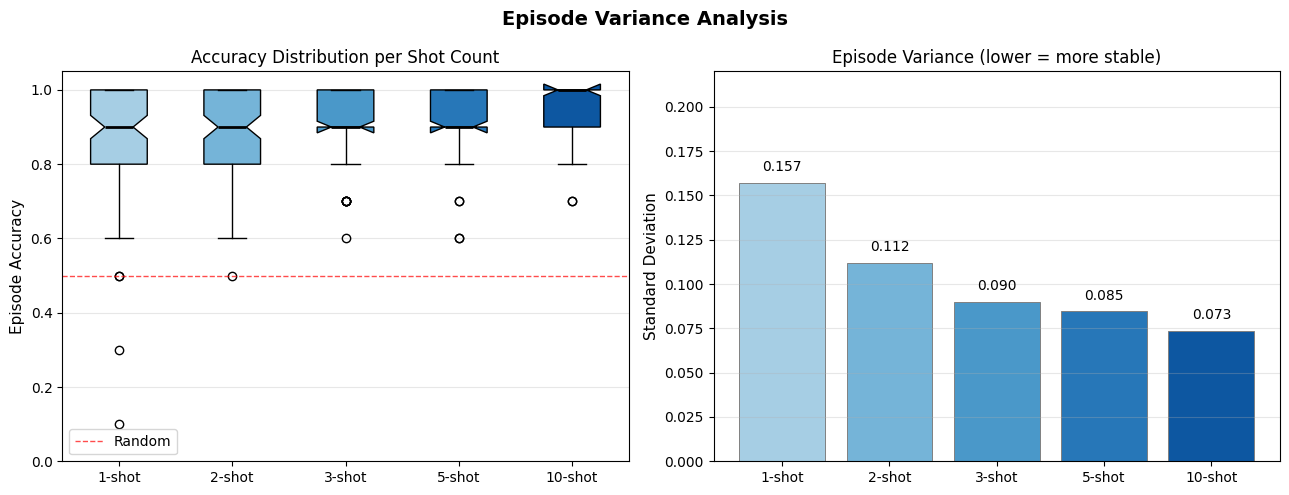

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
data_box = [ablation_results[s] for s in shots]
bp = ax.boxplot(data_box, patch_artist=True, notch=True,
                medianprops=dict(color='black', linewidth=2))
colors = plt.cm.Blues(np.linspace(0.35, 0.85, len(shots)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Random')
ax.set_xticklabels([f'{s}-shot' for s in shots])
ax.set_ylabel('Episode Accuracy', fontsize=11)
ax.set_title('Accuracy Distribution per Shot Count', fontsize=12)
ax.set_ylim(0, 1.05); ax.legend(); ax.grid(axis='y', alpha=0.3)

ax2 = axes[1]
colors2 = plt.cm.Blues(np.linspace(0.35, 0.85, len(shots)))
bars = ax2.bar([f'{s}-shot' for s in shots], stds,
               color=colors2, edgecolor='grey', linewidth=0.7)
ax2.set_ylabel('Standard Deviation', fontsize=11)
ax2.set_title('Episode Variance (lower = more stable)', fontsize=12)
ax2.set_ylim(0, max(stds) * 1.4)
for bar, val in zip(bars, stds):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)
ax2.grid(axis='y', alpha=0.3)

plt.suptitle('Episode Variance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

Running N-shot ablation on UNSEEN classes...
  1-shot: mean=0.850  std=0.157
  2-shot: mean=0.889  std=0.112
  3-shot: mean=0.899  std=0.090
  5-shot: mean=0.916  std=0.085
  10-shot: mean=0.939  std=0.073


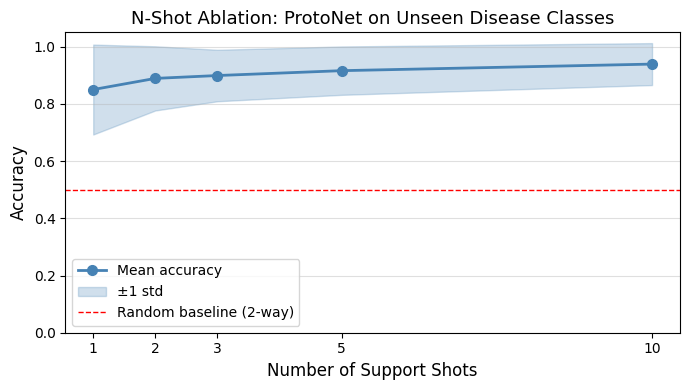

In [15]:
def run_ablation(X_eval, y_eval, shot_list, n_way=2, n_episodes=100):
    results = {}
    embedding_net.eval()
    for n_shot in shot_list:
        min_cls_size = min((y_eval == c).sum() for c in np.unique(y_eval))
        if min_cls_size < n_shot + 5:
            print(f'  Skipping {n_shot}-shot: not enough samples per class')
            continue
        accs = []
        for _ in range(n_episodes):
            with torch.no_grad():
                sx, sy, qx, qy = create_episode(X_eval, y_eval, n_way, n_shot, n_query=5)
                se = embedding_net(sx)
                qe = embedding_net(qx)
                proto = torch.stack([se[sy == i].mean(0) for i in range(n_way)])
                preds = torch.argmin(torch.cdist(qe, proto), dim=1)
            accs.append(accuracy_score(qy.cpu(), preds.cpu()))
        results[n_shot] = accs
        print(f'  {n_shot}-shot: mean={np.mean(accs):.3f}  std={np.std(accs):.3f}')
    return results

shot_list = [1, 2, 3, 5, 10]
print('Running N-shot ablation on UNSEEN classes...')
ablation_results = run_ablation(X_unseen, y_unseen, shot_list, n_way=2, n_episodes=100)

means  = [np.mean(ablation_results[s]) for s in ablation_results]
stds   = [np.std(ablation_results[s])  for s in ablation_results]
shots  = list(ablation_results.keys())

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(shots, means, 'o-', color='steelblue', linewidth=2, markersize=7, label='Mean accuracy')
ax.fill_between(shots,
                [m - s for m, s in zip(means, stds)],
                [m + s for m, s in zip(means, stds)],
                alpha=0.25, color='steelblue', label='±1 std')
ax.axhline(0.5, color='red', linestyle='--', linewidth=1, label='Random baseline (2-way)')
ax.set_xlabel('Number of Support Shots', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('N-Shot Ablation: ProtoNet on Unseen Disease Classes', fontsize=13)
ax.set_xticks(shots)
ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(axis='y', alpha=0.4)
plt.tight_layout(); plt.show()

### ProtoNet Confusion Matrix (single representative episode)

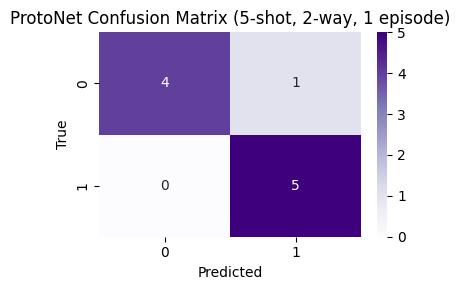

In [8]:
embedding_net.eval()
with torch.no_grad():
    sx, sy, qx, qy = create_episode(X_unseen, y_unseen, n_way=2, n_shot=5, n_query=5)
    se = embedding_net(sx)
    qe = embedding_net(qx)
    proto = torch.stack([se[sy == i].mean(0) for i in range(2)])
    p = torch.argmin(torch.cdist(qe, proto), dim=1)

cm_proto = confusion_matrix(qy.cpu(), p.cpu())
plt.figure(figsize=(4, 3))
sns.heatmap(cm_proto, annot=True, fmt='d', cmap='Purples')
plt.title('ProtoNet Confusion Matrix (5-shot, 2-way, 1 episode)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

In [20]:
import matplotlib.patches as mpatches
from scipy.special import softmax as scipy_softmax

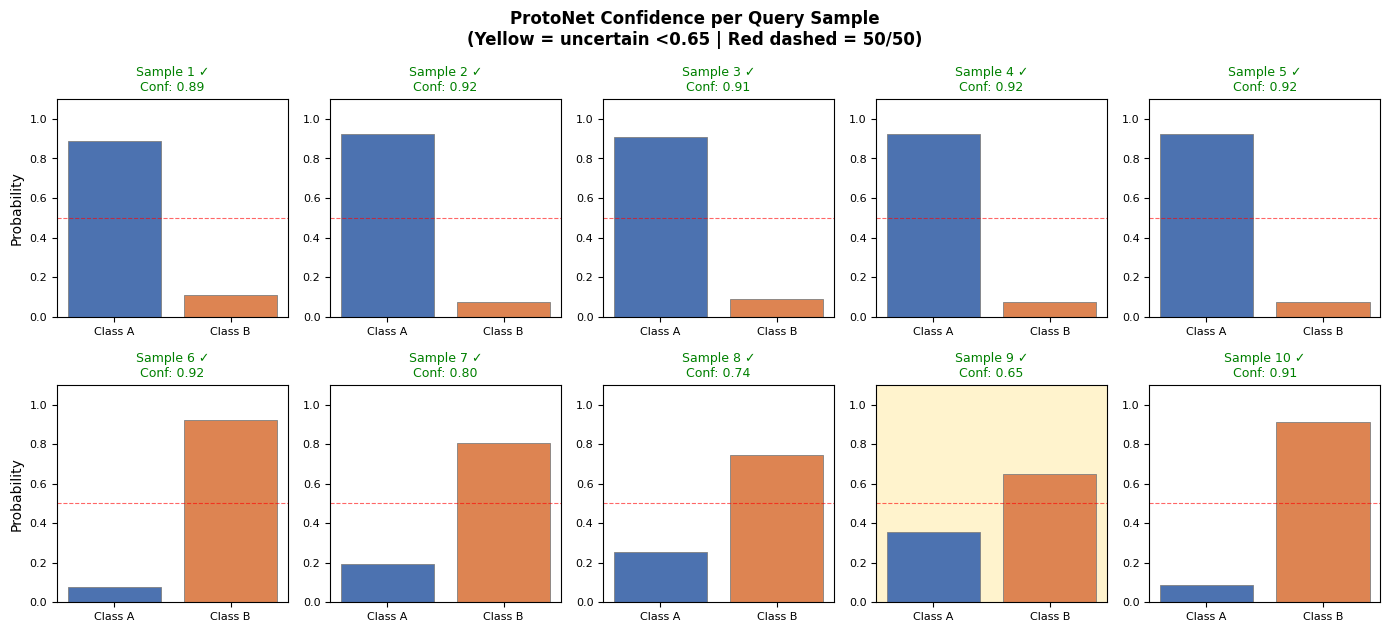

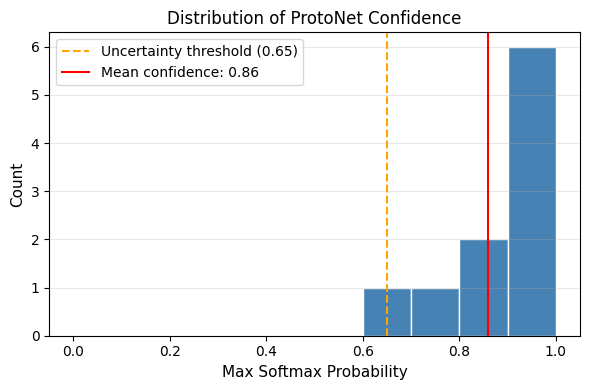

1/10 samples uncertain (max confidence < 0.65)


In [21]:
np.random.seed(7)

embedding_net.eval()
with torch.no_grad():
    sx, sy, qx, qy = create_episode(X_unseen, y_unseen, n_way=2, n_shot=5, n_query=5)
    se    = embedding_net(sx)
    qe    = embedding_net(qx)
    proto = torch.stack([se[sy == i].mean(0) for i in range(2)])
    dists = torch.cdist(qe, proto).cpu().numpy()
    preds = np.argmin(dists, axis=1)
    gt    = qy.cpu().numpy()

probs = scipy_softmax(-dists, axis=1)

n_samples   = len(gt)
n_cols      = 5
n_rows      = (n_samples + n_cols - 1) // n_cols
fig, axes   = plt.subplots(n_rows, n_cols, figsize=(14, 3.2 * n_rows))
axes        = axes.flatten()
colors_bar  = ['#4C72B0', '#DD8452']
class_labels = ['Class A', 'Class B']

for i in range(n_samples):
    ax = axes[i]
    ax.bar(class_labels, probs[i], color=colors_bar, edgecolor='grey', linewidth=0.6)
    ax.set_ylim(0, 1.1)
    ax.axhline(0.5, color='red', linestyle='--', linewidth=0.8, alpha=0.6)
    correct      = preds[i] == gt[i]
    title_color  = 'green' if correct else 'red'
    ax.set_title(f'Sample {i+1} {"✓" if correct else "✗"}\nConf: {probs[i].max():.2f}',
                 color=title_color, fontsize=9)
    ax.set_ylabel('Probability' if i % n_cols == 0 else '')
    ax.tick_params(labelsize=8)
    if probs[i].max() < 0.65:
        ax.set_facecolor('#fff3cd')

for j in range(n_samples, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('ProtoNet Confidence per Query Sample\n'
             '(Yellow = uncertain <0.65 | Red dashed = 50/50)',
             fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()

# Confidence histogram
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(probs.max(axis=1), bins=10, range=(0, 1), color='steelblue', edgecolor='white')
ax.axvline(0.65, color='orange', linestyle='--', label='Uncertainty threshold (0.65)')
ax.axvline(probs.max(axis=1).mean(), color='red', linestyle='-',
           label=f'Mean confidence: {probs.max(axis=1).mean():.2f}')
ax.set_xlabel('Max Softmax Probability', fontsize=11)
ax.set_ylabel('Count', fontsize=11)
ax.set_title('Distribution of ProtoNet Confidence', fontsize=12)
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

n_uncertain = (probs.max(axis=1) < 0.65).sum()
print(f'{n_uncertain}/{n_samples} samples uncertain (max confidence < 0.65)')

 The model was nearly confused between two unseen disease classes it had never seen during training. see tsne for this

Running distance analysis over 30 episodes...


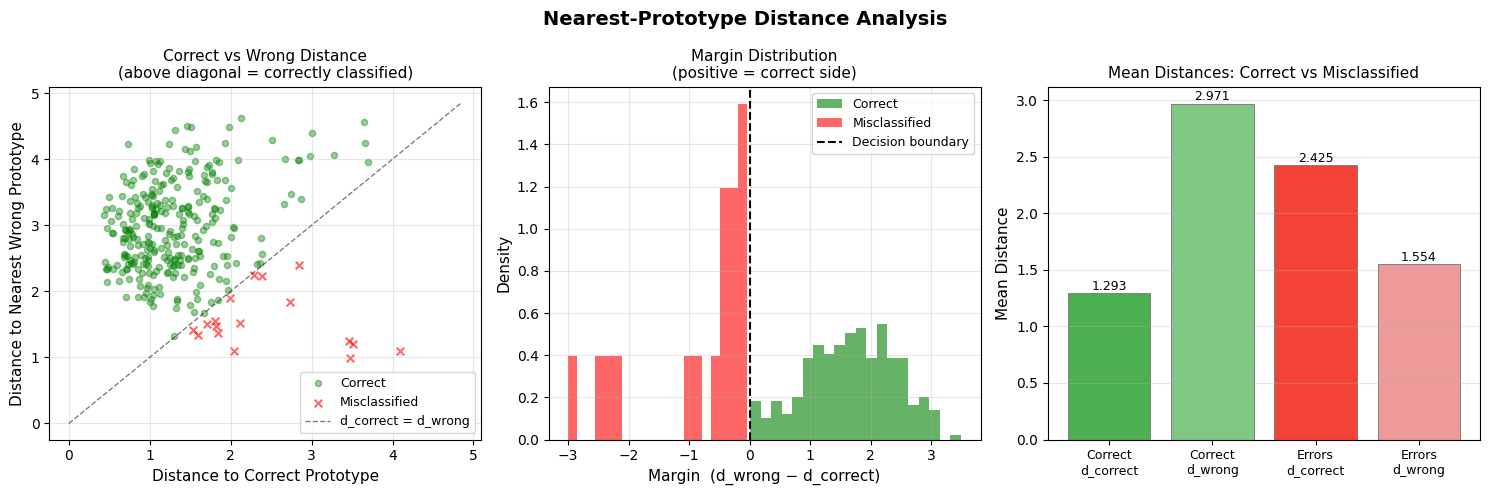

Total samples: 300 | Correct: 283 | Errors: 17
Mean margin — correct: 1.678 | errors: -0.871


In [23]:
def distance_analysis(X_eval, y_eval, n_way=2, n_shot=5, n_episodes=30):
    correct_dists, wrong_dists, margins, is_correct = [], [], [], []
    embedding_net.eval()
    for _ in range(n_episodes):
        with torch.no_grad():
            sx, sy, qx, qy = create_episode(X_eval, y_eval, n_way, n_shot, n_query=5)
            se    = embedding_net(sx)
            qe    = embedding_net(qx)
            proto = torch.stack([se[sy == i].mean(0) for i in range(n_way)])
            dists = torch.cdist(qe, proto).cpu().numpy()
            preds = np.argmin(dists, axis=1)
            gt    = qy.cpu().numpy()
        for i in range(len(gt)):
            d_correct = dists[i, gt[i]]
            d_wrong   = np.min([dists[i, j] for j in range(n_way) if j != gt[i]])
            correct_dists.append(d_correct)
            wrong_dists.append(d_wrong)
            margins.append(d_wrong - d_correct)
            is_correct.append(preds[i] == gt[i])
    return (np.array(correct_dists), np.array(wrong_dists),
            np.array(margins), np.array(is_correct))

print('Running distance analysis over 30 episodes...')
c_dists, w_dists, margins, correct_mask = distance_analysis(X_unseen, y_unseen)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax = axes[0]
ax.scatter(c_dists[correct_mask],  w_dists[correct_mask],
           c='green', alpha=0.4, s=20, label='Correct')
ax.scatter(c_dists[~correct_mask], w_dists[~correct_mask],
           c='red', alpha=0.6, s=30, label='Misclassified', marker='x')
lim = max(c_dists.max(), w_dists.max()) * 1.05
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, alpha=0.5, label='d_correct = d_wrong')
ax.set_xlabel('Distance to Correct Prototype', fontsize=11)
ax.set_ylabel('Distance to Nearest Wrong Prototype', fontsize=11)
ax.set_title('Correct vs Wrong Distance\n(above diagonal = correctly classified)', fontsize=11)
ax.legend(fontsize=9); ax.grid(alpha=0.3)

ax2 = axes[1]
ax2.hist(margins[correct_mask],  bins=20, alpha=0.6, color='green', label='Correct',      density=True)
ax2.hist(margins[~correct_mask], bins=20, alpha=0.6, color='red',   label='Misclassified', density=True)
ax2.axvline(0, color='black', linestyle='--', linewidth=1.5, label='Decision boundary')
ax2.set_xlabel('Margin  (d_wrong − d_correct)', fontsize=11)
ax2.set_ylabel('Density', fontsize=11)
ax2.set_title('Margin Distribution\n(positive = correct side)', fontsize=11)
ax2.legend(fontsize=9); ax2.grid(alpha=0.3)

ax3 = axes[2]
categories  = ['Correct\nd_correct', 'Correct\nd_wrong', 'Errors\nd_correct', 'Errors\nd_wrong']
values      = [c_dists[correct_mask].mean(), w_dists[correct_mask].mean(),
               c_dists[~correct_mask].mean(), w_dists[~correct_mask].mean()]
bar_colors  = ['#4CAF50', '#81C784', '#F44336', '#EF9A9A']
bars        = ax3.bar(categories, values, color=bar_colors, edgecolor='grey', linewidth=0.7)
ax3.set_ylabel('Mean Distance', fontsize=11)
ax3.set_title('Mean Distances: Correct vs Misclassified', fontsize=11)
for bar, val in zip(bars, values):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
             f'{val:.3f}', ha='center', va='bottom', fontsize=9)
ax3.tick_params(axis='x', labelsize=9); ax3.grid(axis='y', alpha=0.3)

plt.suptitle('Nearest-Prototype Distance Analysis', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

print(f'Total samples: {len(correct_mask)} | Correct: {correct_mask.sum()} | Errors: {(~correct_mask).sum()}')
print(f'Mean margin — correct: {margins[correct_mask].mean():.3f} | errors: {margins[~correct_mask].mean():.3f}')

if they're far below, it was confidently wrong



Running 5-split cross-validation (~1-2 min)...

  Split 1 (seed=42): seen=[4 3 6 5] unseen=[2 1] → acc=0.940
  Split 2 (seed=7): seen=[6 3 1 5] unseen=[2 4] → acc=0.624
  Split 3 (seed=123): seen=[5 1 3 4] unseen=[2 6] → acc=0.958
  Split 4 (seed=999): seen=[2 3 1 5] unseen=[4 6] → acc=0.984
  Split 5 (seed=2024): seen=[3 4 5 6] unseen=[2 1] → acc=0.980

Mean: 0.8972  |  Std: 0.1375  |  Range: 0.6240–0.9840


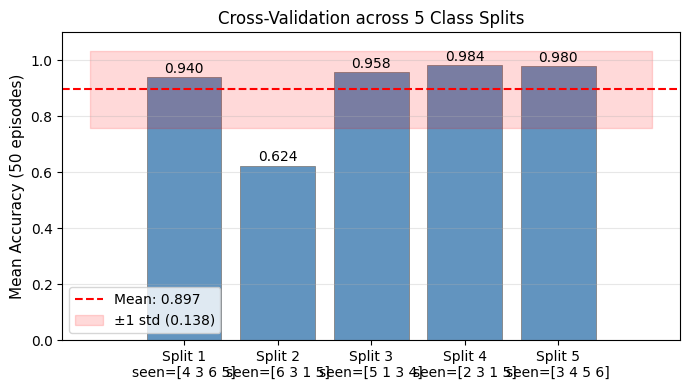

In [24]:
def run_one_split(X, y, unique_classes, seed, n_shot=5, n_way=2, n_episodes=50):
    rng      = np.random.default_rng(seed)
    shuffled = rng.permutation(unique_classes)
    seen_c   = shuffled[:4];  unseen_c = shuffled[4:]

    Xs = X[np.isin(y, seen_c)];   ys = y[np.isin(y, seen_c)]
    Xu = X[np.isin(y, unseen_c)]; yu = y[np.isin(y, unseen_c)]

    if len(np.unique(yu)) < n_way:
        return None, seen_c, unseen_c

    Xtr, _, ytr, _ = train_test_split(Xs, ys, test_size=0.2, random_state=seed, stratify=ys)

    class EmbeddingNetCV(nn.Module):
        def __init__(self, input_dim, embedding_dim=32):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(input_dim, 64), nn.ReLU(),
                                     nn.Linear(64, embedding_dim))
        def forward(self, x): return self.net(x)

    net  = EmbeddingNetCV(X.shape[1]).to(device)
    opt  = optim.Adam(net.parameters(), lr=0.001)
    crit = nn.CrossEntropyLoss()

    net.train()
    for _ in range(300):
        sx, sy, qx, qy = create_episode(Xtr, ytr, 3, 5, 5)
        se, qe = net(sx), net(qx)
        proto  = torch.stack([se[sy == i].mean(0) for i in range(3)])
        loss   = crit(-torch.cdist(qe, proto), qy)
        opt.zero_grad(); loss.backward(); opt.step()

    net.eval()
    accs = []
    for _ in range(n_episodes):
        with torch.no_grad():
            sx, sy, qx, qy = create_episode(Xu, yu, n_way, n_shot, n_query=5)
            se, qe = net(sx), net(qx)
            proto  = torch.stack([se[sy == i].mean(0) for i in range(n_way)])
            preds  = torch.argmin(torch.cdist(qe, proto), dim=1)
        accs.append(accuracy_score(qy.cpu(), preds.cpu()))

    return float(np.mean(accs)), seen_c, unseen_c

seeds      = [42, 7, 123, 999, 2024]
cv_results = []
print('Running 5-split cross-validation (~1-2 min)...\n')

for i, seed in enumerate(seeds):
    acc, seen_c, unseen_c = run_one_split(X, y, np.unique(y), seed)
    if acc is None:
        print(f'  Split {i+1}: skipped'); continue
    cv_results.append({'seed': seed, 'seen': seen_c, 'unseen': unseen_c, 'acc': acc})
    print(f'  Split {i+1} (seed={seed}): seen={seen_c} unseen={unseen_c} → acc={acc:.3f}')

accs_cv = [r['acc'] for r in cv_results]
print(f'\nMean: {np.mean(accs_cv):.4f}  |  Std: {np.std(accs_cv):.4f}  |  '
      f'Range: {np.min(accs_cv):.4f}–{np.max(accs_cv):.4f}')

fig, ax = plt.subplots(figsize=(7, 4))
split_labels = [f'Split {i+1}\nseen={r["seen"]}' for i, r in enumerate(cv_results)]
bars = ax.bar(split_labels, accs_cv, color='steelblue', edgecolor='grey', linewidth=0.7, alpha=0.85)
ax.axhline(np.mean(accs_cv), color='red', linestyle='--', linewidth=1.5,
           label=f'Mean: {np.mean(accs_cv):.3f}')
ax.fill_between(range(-1, len(cv_results) + 1),
                np.mean(accs_cv) - np.std(accs_cv),
                np.mean(accs_cv) + np.std(accs_cv),
                alpha=0.15, color='red', label=f'±1 std ({np.std(accs_cv):.3f})')
ax.set_ylim(0, 1.1)
ax.set_ylabel('Mean Accuracy (50 episodes)', fontsize=11)
ax.set_title('Cross-Validation across 5 Class Splits', fontsize=12)
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, accs_cv):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
            f'{val:.3f}', ha='center', fontsize=10)
plt.tight_layout(); plt.show()

## 8. kNN Baseline

Trained on seen classes only.  
When predicting unseen classes, it can only output seen-class labels → **always 0 accuracy**.  
This is the expected baseline confirming the unseen classes are genuinely novel.

In [9]:
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_seen_train, y_seen_train)
pred_knn = knn.predict(X_unseen)
knn_acc  = accuracy_score(y_unseen, pred_knn)
print(f'kNN Accuracy on Unseen Classes: {knn_acc:.4f}')
print('(Expected ~0.0 — kNN can only predict labels it was trained on)')

kNN Accuracy on Unseen Classes: 0.0000
(Expected ~0.0 — kNN can only predict labels it was trained on)


## 9. MLP Classifier — Trained on Seen Classes, Evaluated on Held-Out Test Set

### Fixes applied:
- evaluated on X_seen_test (20 % hold-out), NOT the training data  
- Added Dropout(0.3) — reduces overfitting, gives realistic accuracy  



In [10]:
class Classifier(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),          # regularisation — prevents memorisation
            nn.Linear(64, num_classes)
        )
    def forward(self, x):
        return self.net(x)

clf     = Classifier(X.shape[1], len(seen_classes)).to(device)
opt_clf = optim.Adam(clf.parameters(), lr=0.001)

# Map original class labels → 0-indexed
label_map      = {c: i for i, c in enumerate(seen_classes)}
y_train_mapped = np.array([label_map[c] for c in y_seen_train])
y_test_mapped  = np.array([label_map[c] for c in y_seen_test])

X_train_t = torch.tensor(X_seen_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train_mapped).long().to(device)

clf.train()
for epoch in range(200):
    out  = clf(X_train_t)
    loss = criterion(out, y_train_t)
    opt_clf.zero_grad(); loss.backward(); opt_clf.step()
    if epoch % 50 == 0:
        print(f'  Epoch {epoch:3d} | Loss: {loss.item():.4f}')

print('\nMLP training complete')

  Epoch   0 | Loss: 1.4307
  Epoch  50 | Loss: 0.2242
  Epoch 100 | Loss: 0.0604
  Epoch 150 | Loss: 0.0269

MLP training complete


=== MLP on SEEN classes — held-out test set ===

  Ground truth : [0 1 0 1 0 3 0 2 0 2 0 0 1 0 2 3 0 0 3 0 0 3 3 0 0 1 1 0 3 0 3 1 1 3 0 0 3
 1 3 3 0 3 1 0 0 2 3 1 3 0 1 0 1]
  Predicted    : [0 1 0 1 0 3 0 2 0 2 0 0 1 0 2 3 0 0 3 0 0 3 3 0 0 1 1 0 3 0 3 1 1 3 0 0 3
 1 3 3 0 3 1 0 0 2 3 1 3 0 1 0 1]

  MLP Accuracy : 1.0000


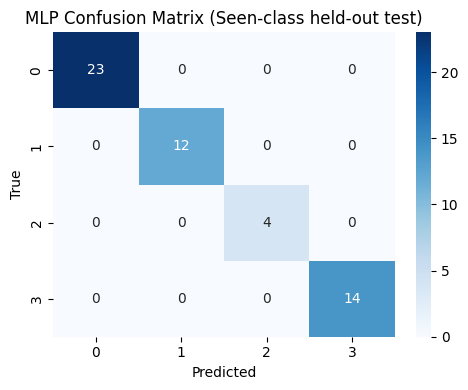

In [11]:
# Evaluate on HELD-OUT test set (FIX 1)
clf.eval()
X_test_t = torch.tensor(X_seen_test, dtype=torch.float32).to(device)

with torch.no_grad():
    logits    = clf(X_test_t)
    mlp_preds = torch.argmax(logits, dim=1).cpu().numpy()

mlp_acc = accuracy_score(y_test_mapped, mlp_preds)

print('=== MLP on SEEN classes — held-out test set ===\n')
print(f'  Ground truth : {y_test_mapped}')
print(f'  Predicted    : {mlp_preds}')
print(f'\n  MLP Accuracy : {mlp_acc:.4f}')

cm_mlp = confusion_matrix(y_test_mapped, mlp_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Blues')
plt.title('MLP Confusion Matrix (Seen-class held-out test)')
plt.xlabel('Predicted'); plt.ylabel('True')
plt.tight_layout(); plt.show()

In [ ]:
# 1. K-Fold Cross Validation — if consistently ~95-100%, it's real
from sklearn.model_selection import cross_val_score
from sklearn.neural_network import MLPClassifier

sklearn_mlp = MLPClassifier(hidden_layer_sizes=(64,), max_iter=300, random_state=42)
scores = cross_val_score(sklearn_mlp, X_seen, y_seen, cv=5)
print(f"5-Fold CV: {scores.round(3)}  |  Mean: {scores.mean():.3f}")



5-Fold CV: [0.981 1.    1.    1.    1.   ]  |  Mean: 0.996


## 10. t-SNE Visualisation of Embeddings

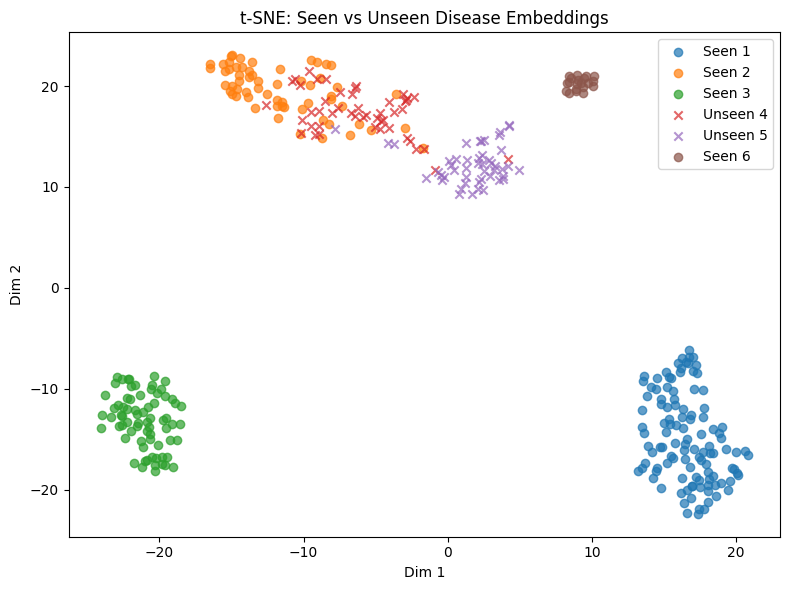

In [12]:
embedding_net.eval()
X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
with torch.no_grad():
    embeddings = embedding_net(X_tensor).cpu().numpy()

tsne   = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(embeddings)

plt.figure(figsize=(8, 6))
for cls in np.unique(y):
    idx    = y == cls
    marker = 'o' if cls in seen_classes else 'x'
    label  = f'Seen {cls}' if cls in seen_classes else f'Unseen {cls}'
    plt.scatter(X_tsne[idx, 0], X_tsne[idx, 1], marker=marker, label=label, alpha=0.7)

plt.legend(); plt.title('t-SNE: Seen vs Unseen Disease Embeddings')
plt.xlabel('Dim 1'); plt.ylabel('Dim 2')
plt.tight_layout(); plt.show()

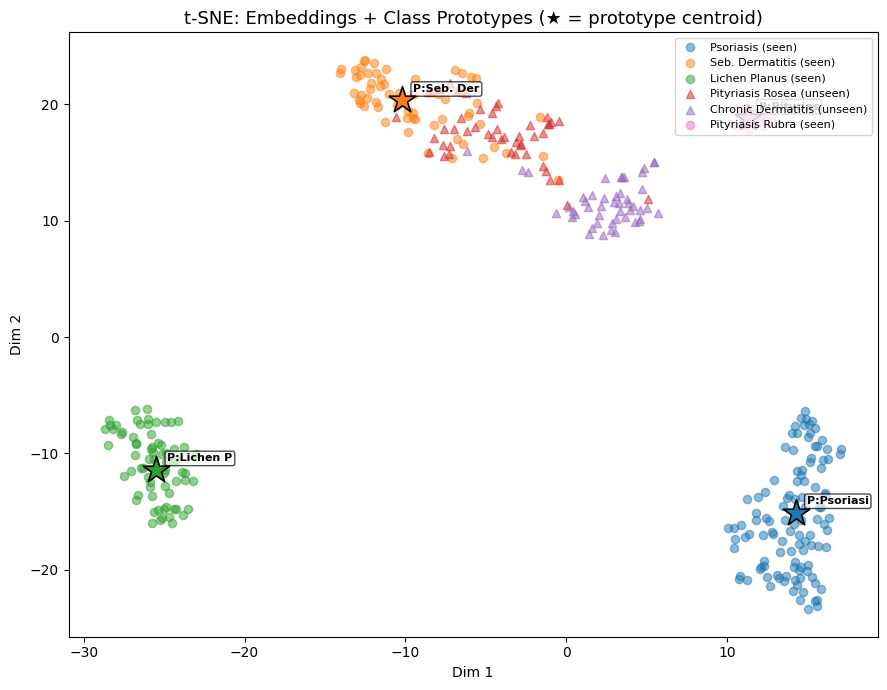

In [18]:
embedding_net.eval()

X_tensor = torch.tensor(X, dtype=torch.float32).to(device)
with torch.no_grad():
    all_emb = embedding_net(X_tensor).cpu().numpy()

prototypes, proto_labels = [], []
for cls in seen_classes:
    cls_idx = np.where(y_seen_train == cls)[0]
    cls_emb = torch.tensor(X_seen_train[cls_idx], dtype=torch.float32).to(device)
    with torch.no_grad():
        proto = embedding_net(cls_emb).mean(0).cpu().numpy()
    prototypes.append(proto)
    proto_labels.append(cls)
prototypes = np.array(prototypes)

combined    = np.vstack([all_emb, prototypes])
tsne = TSNE(n_components=2, perplexity=30, random_state=42, max_iter=1000)

combined_2d = tsne.fit_transform(combined)
sample_2d   = combined_2d[:len(all_emb)]
proto_2d    = combined_2d[len(all_emb):]

disease_names = {1:'Psoriasis', 2:'Seb. Dermatitis', 3:'Lichen Planus',
                 4:'Pityriasis Rosea', 5:'Chronic Dermatitis', 6:'Pityriasis Rubra'}
palette = plt.cm.tab10(np.linspace(0, 0.6, 6))

fig, ax = plt.subplots(figsize=(9, 7))
for i, cls in enumerate(np.unique(y)):
    idx    = y == cls
    color  = palette[i]
    marker = 'o' if cls in seen_classes else '^'
    label  = f'{disease_names.get(cls, cls)} ({"seen" if cls in seen_classes else "unseen"})'
    ax.scatter(sample_2d[idx, 0], sample_2d[idx, 1],
               c=[color], marker=marker, alpha=0.5, s=35, label=label)

for pt, cls in zip(proto_2d, proto_labels):
    color = palette[list(np.unique(y)).index(cls)]
    ax.scatter(pt[0], pt[1], c=[color], marker='*', s=400,
               edgecolors='black', linewidth=1.2, zorder=5)
    ax.annotate(f'P:{disease_names.get(cls, cls)[:8]}', (pt[0], pt[1]),
                textcoords='offset points', xytext=(8, 6), fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax.set_title('t-SNE: Embeddings + Class Prototypes (★ = prototype centroid)', fontsize=13)
ax.legend(loc='upper right', fontsize=8)
ax.set_xlabel('Dim 1'); ax.set_ylabel('Dim 2')
plt.tight_layout(); plt.show()

## 11. Final Comparison Table

> **Important context:** ProtoNet and MLP are evaluated on *different tasks*.  
> - MLP is a standard multi-class classifier for **seen** diseases.  
> - ProtoNet demonstrates **few-shot generalisation to unseen** diseases.  


In [13]:
results = pd.DataFrame({
    'Model': [
        'ProtoNet 1-shot 2-way',
        'ProtoNet 5-shot 2-way',
        'kNN baseline',
        'MLP (with Dropout)',
    ],
    'Accuracy': [
        round(proto_acc_1shot, 4),
        round(proto_acc_5shot, 4),
        round(knn_acc, 4),
        round(mlp_acc, 4),
    ],
    'Evaluated on': [
        'Unseen classes (50-ep avg)',
        'Unseen classes (50-ep avg)',
        'Unseen classes',
        'Seen-class held-out 20% split',
    ],
})
results

,Model,Accuracy,Evaluated on
0,ProtoNet 1-shot 2-way,0.864,Unseen classes (50-ep avg)
1,ProtoNet 5-shot 2-way,0.882,Unseen classes (50-ep avg)
2,kNN baseline,0.000,Unseen classes
3,MLP (with Dropout),1.000,Seen-class held-out 20% split
